In [1]:
# 统一入口：在这里选择 frame，并查看关键路径信息
from pathlib import Path
import re
import numpy as np

PERSON_ID = '21'
ENV_NAME = '夜多い'
ENV_NAME = '昼多い'
FRAME_IDX = 1000

HEAD3D_ROOT = Path('/workspace/data/head3d_fuse_results')
SAM3D_ROOT = Path('/workspace/data/sam3d_body_results_right_full')

FUSED_DIR = HEAD3D_ROOT / PERSON_ID / ENV_NAME / 'smoothed_fused_npz'
FUSED_FILE_PATH = FUSED_DIR / f'frame_{FRAME_IDX:06d}_fused.npy'

available_frames = []
if FUSED_DIR.exists():
    for p in sorted(FUSED_DIR.glob('frame_*_fused.npy')):
        m = re.search(r'frame_(\d+)_fused\.npy$', p.name)
        if m:
            available_frames.append(int(m.group(1)))

print('=== Frame Selection ===')
print(f'PERSON_ID: {PERSON_ID}')
print(f'ENV_NAME: {ENV_NAME}')
print(f'FRAME_IDX: {FRAME_IDX}')
print(f'FUSED_DIR: {FUSED_DIR} | exists={FUSED_DIR.exists()}')
print(f'FUSED_FILE_PATH: {FUSED_FILE_PATH} | exists={FUSED_FILE_PATH.exists()}')
print(f'available frame count: {len(available_frames)}')
if available_frames:
    print(f'frame range: [{available_frames[0]}, {available_frames[-1]}]')
    print(f'first 10 frames: {available_frames[:10]}')

print('\n=== Expected NPZ Paths ===')
for view in ['front', 'left', 'right']:
    p = SAM3D_ROOT / PERSON_ID / ENV_NAME / view / f'{FRAME_IDX:06d}_sam3d_body.npz'
    print(f'{view:>5}: {p} | exists={p.exists()}')

data = np.load(FUSED_FILE_PATH, allow_pickle=True)

=== Frame Selection ===
PERSON_ID: 21
ENV_NAME: 昼多い
FRAME_IDX: 1000
FUSED_DIR: /workspace/data/head3d_fuse_results/21/昼多い/smoothed_fused_npz | exists=True
FUSED_FILE_PATH: /workspace/data/head3d_fuse_results/21/昼多い/smoothed_fused_npz/frame_001000_fused.npy | exists=True
available frame count: 9845
frame range: [204, 10211]
first 10 frames: [204, 205, 206, 207, 208, 209, 210, 211, 212, 213]

=== Expected NPZ Paths ===
front: /workspace/data/sam3d_body_results_right_full/21/昼多い/front/001000_sam3d_body.npz | exists=True
 left: /workspace/data/sam3d_body_results_right_full/21/昼多い/left/001000_sam3d_body.npz | exists=True
right: /workspace/data/sam3d_body_results_right_full/21/昼多い/right/001000_sam3d_body.npz | exists=True


In [2]:
info = data.item()
info.keys()

dict_keys(['frame_idx', 'fused_keypoints_3d', 'fused_mask', 'valid_views', 'npz_paths'])

In [3]:
for key in info.keys():
    print(f'{key}: {type(info[key])}')

frame_idx: <class 'int'>
fused_keypoints_3d: <class 'numpy.ndarray'>
fused_mask: <class 'NoneType'>
valid_views: <class 'int'>
npz_paths: <class 'dict'>


In [4]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

sys.path.append('/workspace/code')

from vis_3d_kpt.metadata.mhr70_drive import (
    get_head_hand_indices_mapping,
    pose_info as mhr70_pose_info,
 )
from vis_3d_kpt.visualization.scene_visualizer import SceneVisualizer

scene_visualizer = SceneVisualizer(line_width=2, radius=5)
scene_visualizer.set_pose_meta(mhr70_pose_info)


def visualize_part_comparison(
    keypoints_3d: np.ndarray,
    selected_parts=None,
 ):
    mapping = get_head_hand_indices_mapping()

    head_indices = mapping['head']['indices']
    left_hand_indices = mapping['left_hand']['indices']
    right_hand_indices = mapping['right_hand']['indices']
    left_arm_indices = [5, 7, 62]
    right_arm_indices = [6, 8, 41]

    part_style = {
        'head': dict(indices=head_indices, point_color='red', line_color='red', label=f"Head ({len(head_indices)} pts)"),
        'left_hand': dict(indices=left_hand_indices, point_color='blue', line_color='blue', label=f"Left Hand ({len(left_hand_indices)} pts)"),
        'right_hand': dict(indices=right_hand_indices, point_color='green', line_color='green', label=f"Right Hand ({len(right_hand_indices)} pts)"),
        'left_arm': dict(indices=left_arm_indices, point_color='orange', line_color='orange', label='Left Arm (3 pts)'),
        'right_arm': dict(indices=right_arm_indices, point_color='purple', line_color='purple', label='Right Arm (3 pts)'),
    }

    if selected_parts is None:
        selected_parts = ['head', 'left_arm', 'right_arm', 'left_hand', 'right_hand']

    edges, _ = scene_visualizer.get_skeleton_edges_with_colors()

    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    for part_name in selected_parts:
        if part_name not in part_style:
            continue
        style = part_style[part_name]
        indices = style['indices']
        part_kpts = keypoints_3d[indices]

        ax.scatter(
            part_kpts[:, 0],
            part_kpts[:, 1],
            part_kpts[:, 2],
            c=style['point_color'],
            s=50,
            alpha=0.95,
            label=style['label'],
        )

        scene_visualizer.draw_skeleton_edges(
            ax=ax,
            keypoints_3d=keypoints_3d,
            edges=edges,
            colors=[style['line_color']] * len(edges),
            part_index_set=set(indices),
            linewidth=2.4,
            alpha=0.9,
        )

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    # ax.set_title(f"{title_prefix} - Parts in One Coordinate System")
    # ax.legend(loc='upper right')
    # ax.view_init(elev=20, azim=45)
    plt.tight_layout()

    return fig, ax

✅ 已保存: /workspace/code/logs/vis_3d_kpt/part_comparison_single_file.png


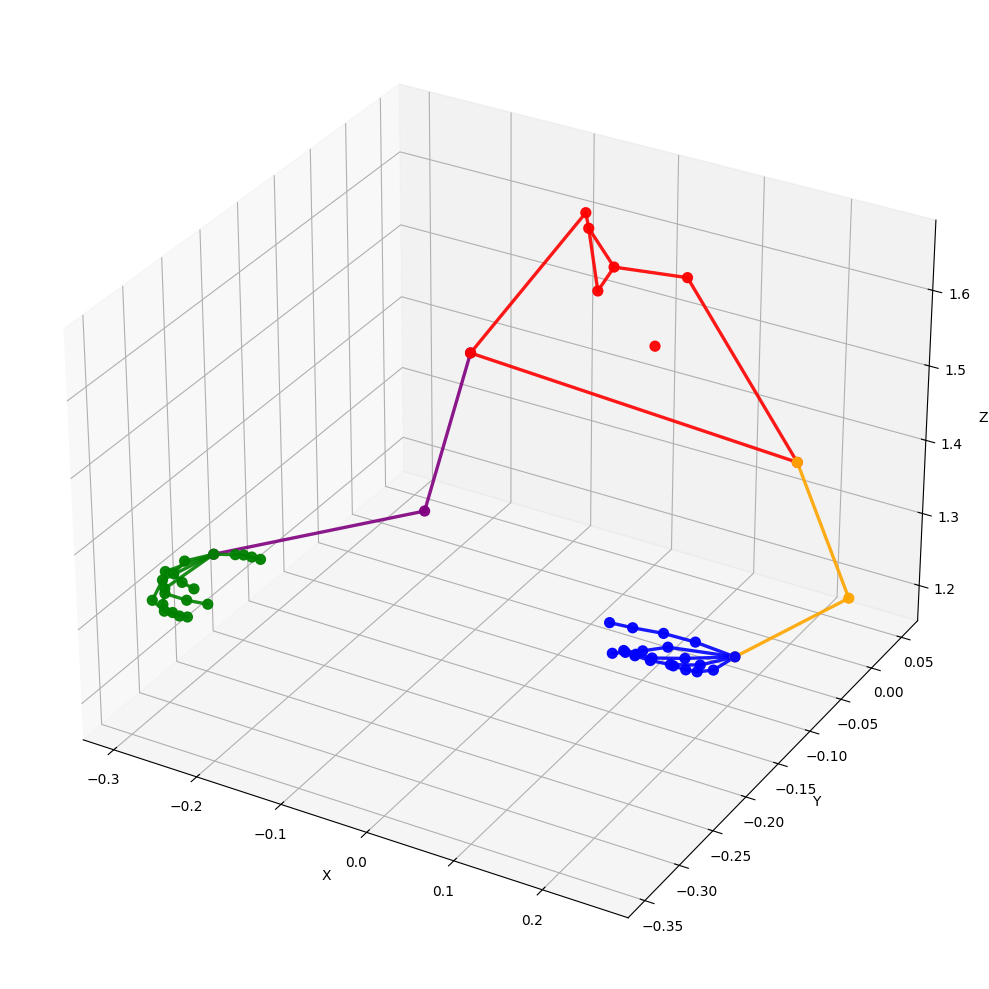

In [5]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# 1) 优先复用第 1 个代码单元的选择
default_file = '/workspace/data/head3d_fuse_results/01/夜多い/smoothed_fused_npz/frame_000623_fused.npy'
FILE_PATH = Path(globals().get('FUSED_FILE_PATH', default_file))

# 2) 加载数据
arr = np.load(FILE_PATH, allow_pickle=True)
sample = arr.item() if isinstance(arr, np.ndarray) and arr.dtype == object else arr

if not isinstance(sample, dict):
    raise TypeError(f'Expected dict in npy, got: {type(sample)}')

if 'fused_keypoints_3d' not in sample:
    raise KeyError("Missing key 'fused_keypoints_3d' in loaded file")

kpts3d = sample['fused_keypoints_3d']
frame_idx = sample.get('frame_idx', 'unknown')

# 3) 可视化（可选: 仅头部 或 头+手臂+手）
selected_parts = ['head', 'left_arm', 'right_arm', 'left_hand', 'right_hand']
# y 和 z 交换显示，并且交换之后的z需要取负数，使得显示更符合常规习惯
kpts3d[:, [1, 2]] = kpts3d[:, [2, 1]]
kpts3d[:, 2] = -kpts3d[:, 2]

fig, ax = visualize_part_comparison(
    keypoints_3d=kpts3d,
    selected_parts=selected_parts,
 )

# 4) 保存图片
save_path = Path('/workspace/code/logs/vis_3d_kpt/part_comparison_single_file.png')
save_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'✅ 已保存: {save_path}')

plt.show()
plt.close(fig)

当前文件: /workspace/data/head3d_fuse_results/21/昼多い/smoothed_fused_npz/frame_001000_fused.npy
frame_idx: 1000
keypoints shape: (70, 3)
camera: ELEV=18, FRONT_AZIM=-90
3D figure size: (15, 5), axis pad ratio: 0.35
开始绘制融合后关键点的三个观察视角...


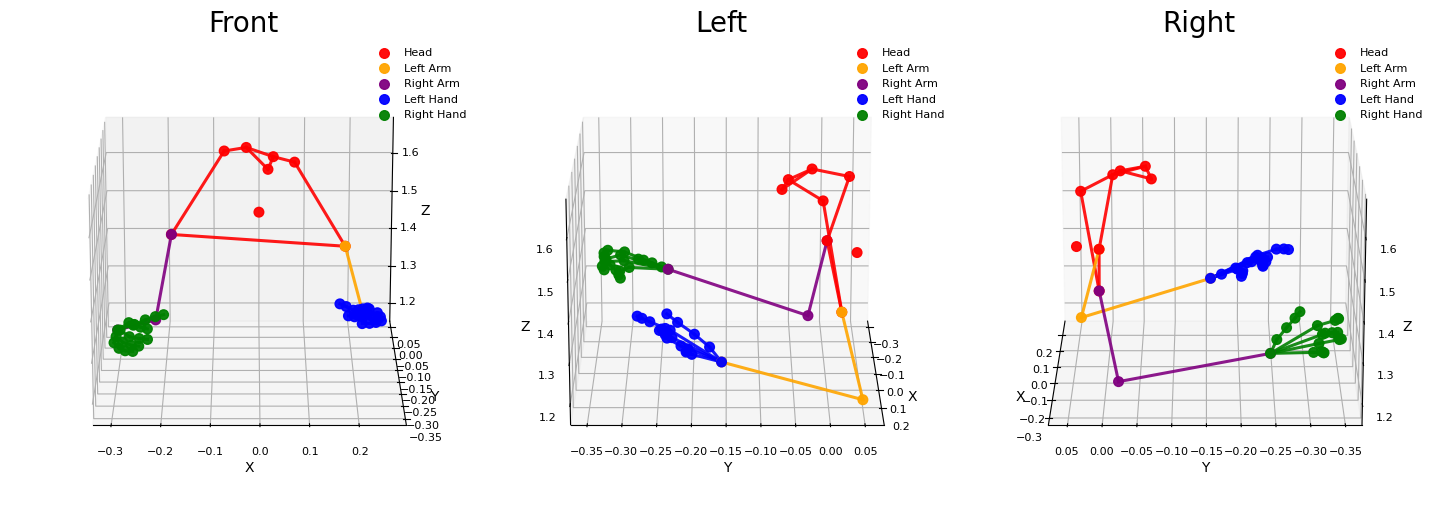

In [6]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import sys

# 1) 优先复用第 1 个代码单元的选择
default_file = '/workspace/data/head3d_fuse_results/01/夜多い/smoothed_fused_npz/frame_000623_fused.npy'
FILE_PATH = Path(globals().get('FUSED_FILE_PATH', default_file))

# 2) 读取融合后的关键点
arr = np.load(FILE_PATH, allow_pickle=True)
sample = arr.item() if isinstance(arr, np.ndarray) and arr.dtype == object else arr

if not isinstance(sample, dict):
    raise TypeError(f'Expected dict in npy, got: {type(sample)}')

if 'fused_keypoints_3d' not in sample:
    raise KeyError("Missing key 'fused_keypoints_3d' in loaded file")

kpts3d = np.asarray(sample['fused_keypoints_3d']).copy()
frame_idx = int(sample.get('frame_idx', -1))

# 3) 显示层坐标变换（仅用于可视化）
# y 和 z 交换；交换后的 z 取负，使显示更符合当前使用习惯
kpts3d_plot = kpts3d[:, [0, 2, 1]].copy()
kpts3d_plot[:, 2] = -kpts3d_plot[:, 2]

selected_parts = ['head', 'left_arm', 'right_arm', 'left_hand', 'right_hand']

# 坐标系和画布大小参数（这里可调）
AXIS_PAD_RATIO_3D = 0.35  # 越大，坐标范围越大
FIG_SIZE_3D = (15, 5)

sys.path.append('/workspace/code')
from vis_3d_kpt.metadata.mhr70_drive import get_head_hand_indices_mapping, pose_info as mhr70_pose_info
from vis_3d_kpt.visualization.scene_visualizer import SceneVisualizer

if 'scene_visualizer' not in globals():
    scene_visualizer = SceneVisualizer(line_width=2, radius=5)
    scene_visualizer.set_pose_meta(mhr70_pose_info)


def _draw_part_comparison_on_ax(ax, keypoints_3d: np.ndarray, selected_parts=None):
    mapping = get_head_hand_indices_mapping()

    head_indices = mapping['head']['indices']
    left_hand_indices = mapping['left_hand']['indices']
    right_hand_indices = mapping['right_hand']['indices']
    left_arm_indices = [5, 7, 62]
    right_arm_indices = [6, 8, 41]

    part_style = {
        'head': dict(indices=head_indices, point_color='red', line_color='red', label='Head'),
        'left_hand': dict(indices=left_hand_indices, point_color='blue', line_color='blue', label='Left Hand'),
        'right_hand': dict(indices=right_hand_indices, point_color='green', line_color='green', label='Right Hand'),
        'left_arm': dict(indices=left_arm_indices, point_color='orange', line_color='orange', label='Left Arm'),
        'right_arm': dict(indices=right_arm_indices, point_color='purple', line_color='purple', label='Right Arm'),
    }

    if selected_parts is None:
        selected_parts = ['head', 'left_arm', 'right_arm', 'left_hand', 'right_hand']

    edges, _ = scene_visualizer.get_skeleton_edges_with_colors()

    for part_name in selected_parts:
        if part_name not in part_style:
            continue
        style = part_style[part_name]
        indices = style['indices']
        part_kpts = keypoints_3d[indices]

        ax.scatter(
            part_kpts[:, 0],
            part_kpts[:, 1],
            part_kpts[:, 2],
            c=style['point_color'],
            s=48,
            alpha=0.95,
            label=style['label'],
        )

        scene_visualizer.draw_skeleton_edges(
            ax=ax,
            keypoints_3d=keypoints_3d,
            edges=edges,
            colors=[style['line_color']] * len(edges),
            part_index_set=set(indices),
            linewidth=2.2,
            alpha=0.9,
        )

    ax.set_xlabel('X', labelpad=1)
    ax.set_ylabel('Y', labelpad=1)
    ax.set_zlabel('Z', labelpad=1)
    ax.legend(loc='upper right', fontsize=8, frameon=False)


def _set_equal_3d_axes(ax, points: np.ndarray, pad_ratio: float = 0.35):
    mins = np.min(points, axis=0)
    maxs = np.max(points, axis=0)
    center = (mins + maxs) / 2.0
    spans = np.maximum(maxs - mins, 1e-6)
    radius = (np.max(spans) * (1.0 + pad_ratio)) / 2.0

    ax.set_xlim(center[0] - radius, center[0] + radius)
    ax.set_ylim(center[1] - radius, center[1] + radius)
    ax.set_zlim(center[2] - radius, center[2] + radius)
    ax.set_box_aspect((1, 1, 1))


# 4) 从三个视角绘制同一份“融合后”关键点
# 这里是观察角度，不是再次读取三个视角的数据
# 你只需要调 FRONT_AZIM 就可以整体转正，left/right 会自动跟随
ELEV = 18
FRONT_AZIM = -90  # 如果正反不对可改成 90

VIEW_CAMERA = {
    'Front': (ELEV, FRONT_AZIM),
    'Left': (ELEV, FRONT_AZIM + 90),
    'Right': (ELEV, FRONT_AZIM - 90),
}

print(f'当前文件: {FILE_PATH}')
print(f'frame_idx: {frame_idx}')
print(f'keypoints shape: {kpts3d.shape}')
print(f'camera: ELEV={ELEV}, FRONT_AZIM={FRONT_AZIM}')
print(f'3D figure size: {FIG_SIZE_3D}, axis pad ratio: {AXIS_PAD_RATIO_3D}')
print('开始绘制融合后关键点的三个观察视角...')

fig = plt.figure(figsize=FIG_SIZE_3D)
fig.subplots_adjust(left=0.02, right=0.98, bottom=0.06, top=0.88, wspace=0.02)

for idx, (view_name, (elev, azim)) in enumerate(VIEW_CAMERA.items(), start=1):
    ax = fig.add_subplot(1, 3, idx, projection='3d')
    _draw_part_comparison_on_ax(ax, kpts3d_plot, selected_parts=selected_parts)
    ax.view_init(elev=elev, azim=azim)
    ax.set_title(view_name, pad=2, fontsize=20)
    ax.tick_params(labelsize=8)

plt.tight_layout(pad=0.2)
plt.show()
plt.close(fig)

frame_idx: 1000
front: path=/workspace/data/sam3d_body_results_right_full/21/昼多い/front/001000_sam3d_body.npz | exists=True | frame_shape=(224, 332, 3)
 left: path=/workspace/data/sam3d_body_results_right_full/21/昼多い/left/001000_sam3d_body.npz | exists=True | frame_shape=(224, 330, 3)
right: path=/workspace/data/sam3d_body_results_right_full/21/昼多い/right/001000_sam3d_body.npz | exists=True | frame_shape=(224, 332, 3)


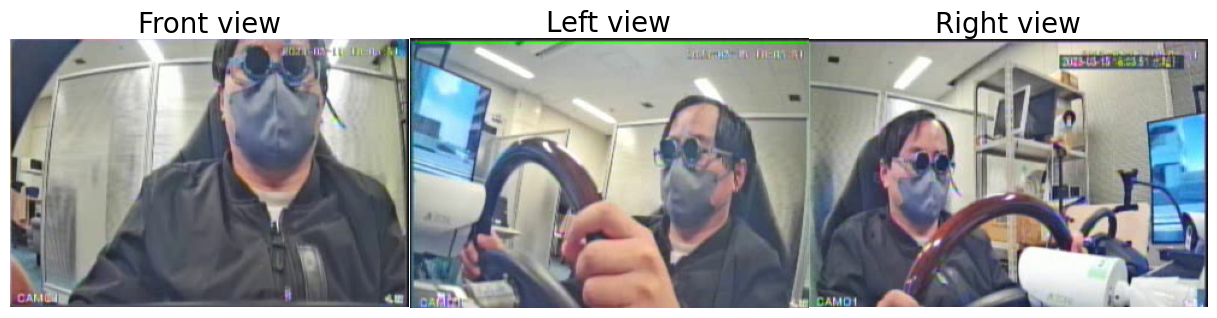

In [7]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# 复用前面单元中的上下文变量
_local_sample = globals().get('sample', {})
_local_frame_idx = int(globals().get('frame_idx', globals().get('FRAME_IDX', -1)))
_local_person_id = str(globals().get('PERSON_ID', '01'))
_local_env_name = str(globals().get('ENV_NAME', '夜多い'))
_local_sam3d_root = Path(globals().get('SAM3D_ROOT', '/workspace/data/sam3d_body_results_right_full'))
_local_color_order = str(globals().get('FRAME_COLOR_ORDER', 'RGB')).upper()

# 优先使用融合文件里记录的 npz_paths；若不存在则按规则推断
npz_paths = {}
if isinstance(_local_sample, dict):
    npz_paths = _local_sample.get('npz_paths', {}) or {}

if not npz_paths:
    npz_paths = {
        view: _local_sam3d_root / _local_person_id / _local_env_name / view / f'{_local_frame_idx:06d}_sam3d_body.npz'
        for view in ['front', 'left', 'right']
    }


def _load_frame_from_npz(npz_path: Path):
    if not npz_path.exists():
        return None
    with np.load(npz_path, allow_pickle=True) as z:
        if 'frame' in z.files:
            return z['frame']
        if 'output' in z.files:
            out = z['output'].item()
            if isinstance(out, dict):
                return out.get('frame', None)
    return None


views = ['front', 'left', 'right']
frames = {view: _load_frame_from_npz(Path(npz_paths[view])) for view in views if view in npz_paths}

direction_labels = {
    'front': 'Front view',
    'left': 'Left view',
    'right': 'Right view',
}

print(f'frame_idx: {_local_frame_idx}')
for view in views:
    p = Path(npz_paths[view]) if view in npz_paths else None
    f = frames.get(view)
    print(f'{view:>5}: path={p} | exists={p.exists() if p else False} | frame_shape={None if f is None else f.shape}')

# 一张图内显示三个视角，尽量紧凑
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.subplots_adjust(left=0.01, right=0.99, bottom=0.02, top=0.88, wspace=0.03)

for i, view in enumerate(views):
    ax = axes[i]
    frame_img = frames.get(view)

    if frame_img is None:
        ax.text(0.5, 0.5, 'No frame', ha='center', va='center', fontsize=13)
    else:
        if frame_img.ndim == 3 and frame_img.shape[-1] == 3:
            if _local_color_order == 'BGR':
                ax.imshow(frame_img[..., ::-1])
            else:
                ax.imshow(frame_img)
        else:
            ax.imshow(frame_img, cmap='gray')

    ax.set_title(direction_labels.get(view, view), fontsize=20, pad=2)
    ax.axis('off')

plt.tight_layout(pad=0.1)
plt.show()
plt.close(fig)